In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from IPython.display import Image, display

import gc
import itertools

```python
"""
Paths:
Chunk0950                    [001_007]
Chunk1000                    [001_005, 006_009]
Chunk1010                    [001_005, 006_010]
Chunk1020                    [001_007]
Chunk1030                    [001_005, 006_011]
Chunk1040                    [001_007]
Chunk1050                    [001_005, 006_010]
Chunk1100                    [001_005, 006_009]
Chunk1110                    [001_005]
Chunk1120                    [001_005, 006_011]
Chunk1130                    [001_008]
Chunk1140                    [001_006, 007_011]
Chunk1150                    [001_007]
Chunk1200                    [001_006, 007_011]
Chunk1210                    [001_008]
Chunk1220                    [001_008]
Chunk1300                    [001_006, 003, 007_010]
"""
```

In [2]:
base_path = ""
which_file = "pairs"
which_chunk = "Chunk1300"
which_number = ["001_006","003","007_010"]
N_SPLITS = 10
file_names = [""]*N_SPLITS*len(which_number)
for num in range (len(which_number)):
    path = base_path + "_".join([which_file, which_chunk, which_number[num]])
    for i in range(N_SPLITS):
        file_names[i+N_SPLITS*num] = ( path + f"_{i}.pkl" )
print(file_names)

['pairs_Chunk1300_001_006_0.pkl', 'pairs_Chunk1300_001_006_1.pkl', 'pairs_Chunk1300_001_006_2.pkl', 'pairs_Chunk1300_001_006_3.pkl', 'pairs_Chunk1300_001_006_4.pkl', 'pairs_Chunk1300_001_006_5.pkl', 'pairs_Chunk1300_001_006_6.pkl', 'pairs_Chunk1300_001_006_7.pkl', 'pairs_Chunk1300_001_006_8.pkl', 'pairs_Chunk1300_001_006_9.pkl', 'pairs_Chunk1300_003_0.pkl', 'pairs_Chunk1300_003_1.pkl', 'pairs_Chunk1300_003_2.pkl', 'pairs_Chunk1300_003_3.pkl', 'pairs_Chunk1300_003_4.pkl', 'pairs_Chunk1300_003_5.pkl', 'pairs_Chunk1300_003_6.pkl', 'pairs_Chunk1300_003_7.pkl', 'pairs_Chunk1300_003_8.pkl', 'pairs_Chunk1300_003_9.pkl', 'pairs_Chunk1300_007_010_0.pkl', 'pairs_Chunk1300_007_010_1.pkl', 'pairs_Chunk1300_007_010_2.pkl', 'pairs_Chunk1300_007_010_3.pkl', 'pairs_Chunk1300_007_010_4.pkl', 'pairs_Chunk1300_007_010_5.pkl', 'pairs_Chunk1300_007_010_6.pkl', 'pairs_Chunk1300_007_010_7.pkl', 'pairs_Chunk1300_007_010_8.pkl', 'pairs_Chunk1300_007_010_9.pkl']


In [3]:
%%bash
cat "Cuts_for_Chunk0950_001_007.txt"

(( (fNsigmaTOFpi > -5) & (fNsigmaTOFpi < 5) ) | ( (fNsigmaTOFka > -5) & (fNsigmaTOFka < 5) )   )

In [4]:
bucket = []
for item in file_names:
    bucket.append( pd.read_pickle(item)  )
    
df = pd.concat(bucket, ignore_index=True)
 # Debug
print("The starting dataframe has", len(df), "rows and ", len(df.columns), "columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The starting dataframe occupies {memory:.2f} MB")
df.head()

The starting dataframe has 2769392 rows and  8 columns.
The starting dataframe occupies 169.03 MB


,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing
0,1,-9.161498e-08,2.252138,2.069586,3.217463,-2.592241,0.008982,0.973469
1,1,-4.235105e-05,2.429784,2.384288,0.726557,-0.334048,0.011494,-0.782104
2,10,-2.577115e-06,1.198978,0.978138,1.859134,1.160531,0.013422,-0.992941
3,10,2.069840e-06,1.198752,0.913769,1.541767,1.401276,0.004507,-0.949709
4,18,-4.016381e-07,2.923491,2.985932,1.163688,0.795340,0.009846,-0.675431


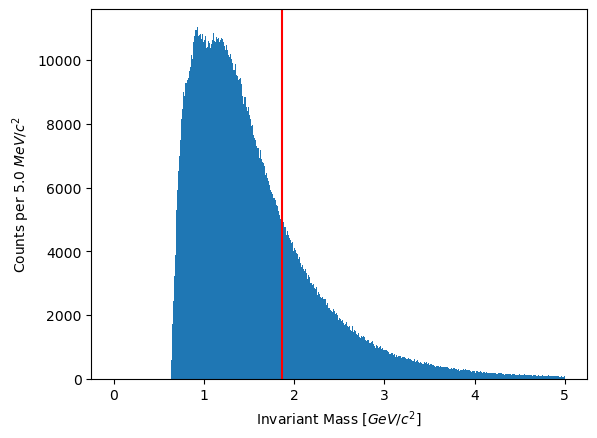

In [5]:
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

# Variables for Plot
MIN_MASS = 0
MAX_MASS = 5
N_BINS = int(1e+03)

# Dummy plot: this takes the same collision index multiple times, with no filtering.
plt.hist(df["inv_mass"], range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000)} $MeV/c^2$")
plt.show()

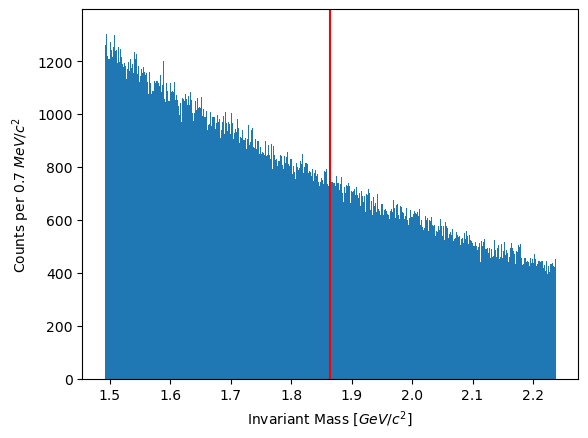

In [6]:
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
mass_mask = df["inv_mass"].between(MIN_MASS, MAX_MASS)
plt.hist(df["inv_mass"][mass_mask], range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.show()

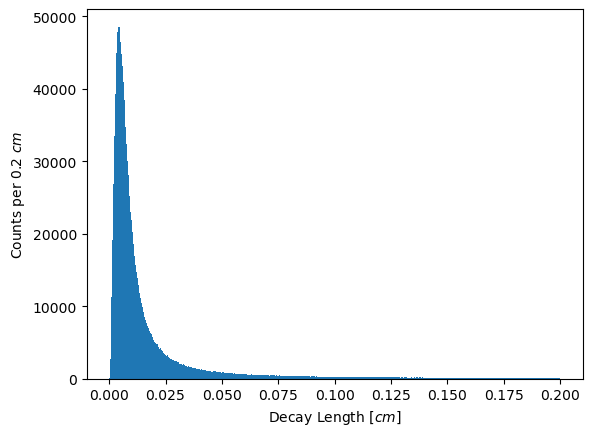

In [7]:
MIN_L, MAX_L = 0, 0.2
plt.hist(df["decay_length"], range=(MIN_L, MAX_L), bins=N_BINS)
plt.xlabel("Decay Length $[cm]$")
plt.ylabel(f"Counts per {((MAX_L-MIN_L)/N_BINS *1000):.1f} $cm$")
plt.show()

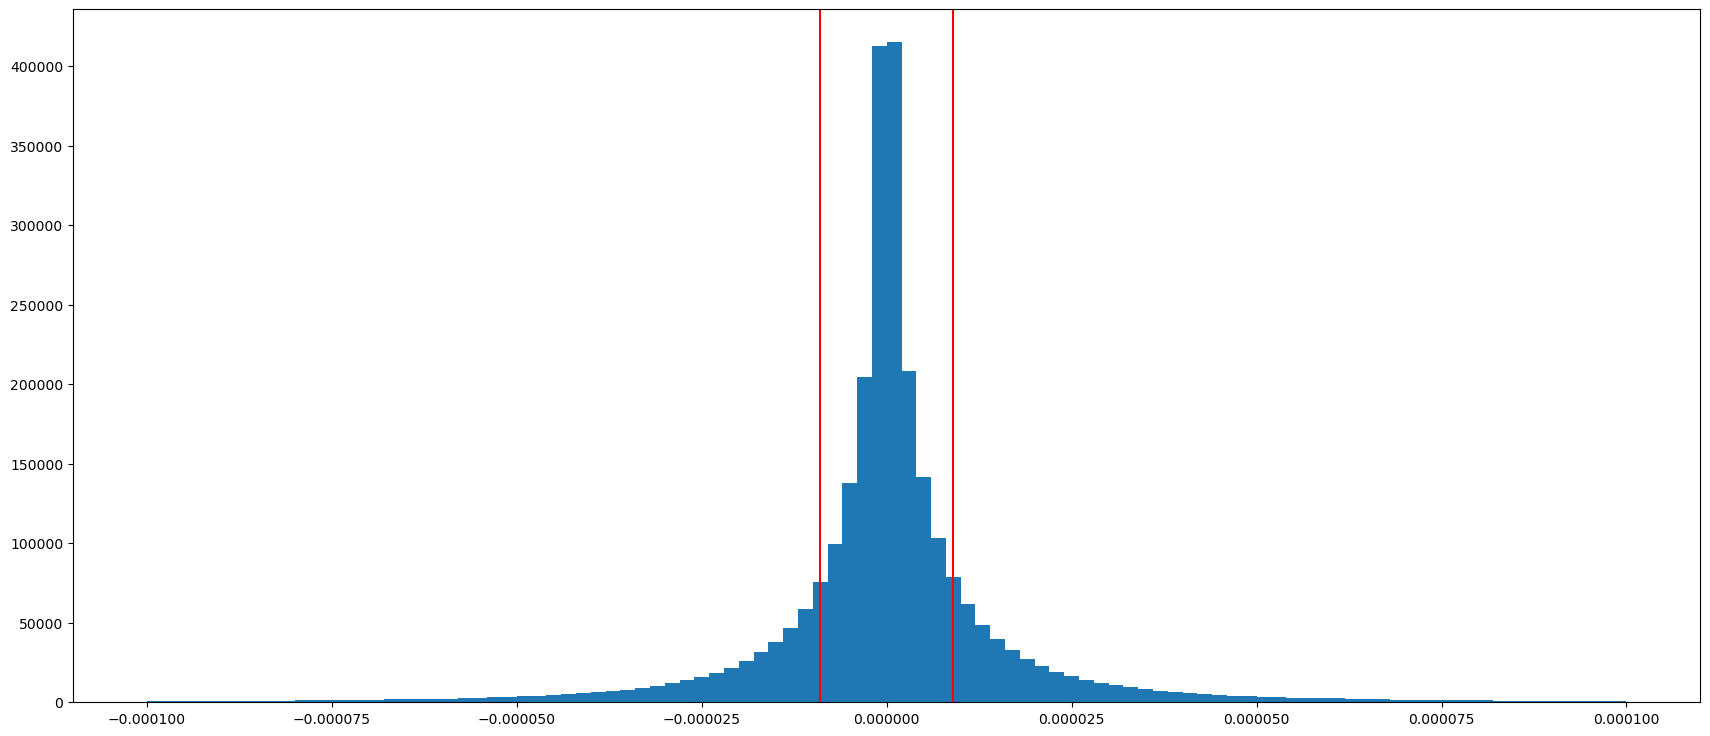

In [8]:
fig, ax = plt.subplots(figsize=(21,9))
plt.hist(df["dcaXY_product"], range=(-1e-04,1e-04), bins=100)
plt.axvline(x=(3e-03)**2, color="red")
plt.axvline(x=-(3e-03)**2, color="red")
plt.show()

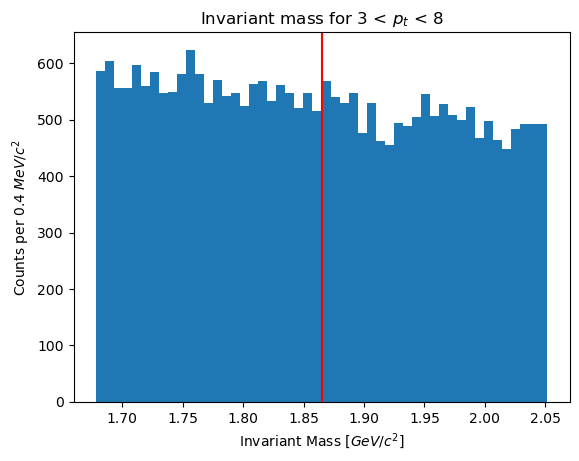

In [9]:
# pt in GeV/c
MIN_PT, MAX_PT = 3, 8
pt_mask = df["pt"].between(MIN_PT, MAX_PT)
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
plt.hist(df["inv_mass"][pt_mask],range=(MIN_MASS,MAX_MASS), bins=50)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.title(f"Invariant mass for {MIN_PT} < $p_t$ < {MAX_PT}")
plt.show()

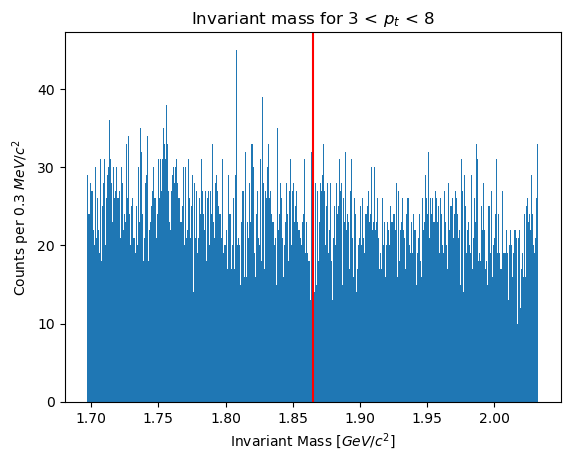

In [10]:
MIN_PT, MAX_PT = 3, 8
pt_mask = df["pt"].between(MIN_PT, MAX_PT)
MIN_MASS, MAX_MASS = 0.91*m_d0, 1.09*m_d0
plt.hist(df["inv_mass"][pt_mask],range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.title(f"Invariant mass for {MIN_PT} < $p_t$ < {MAX_PT}")
plt.show()

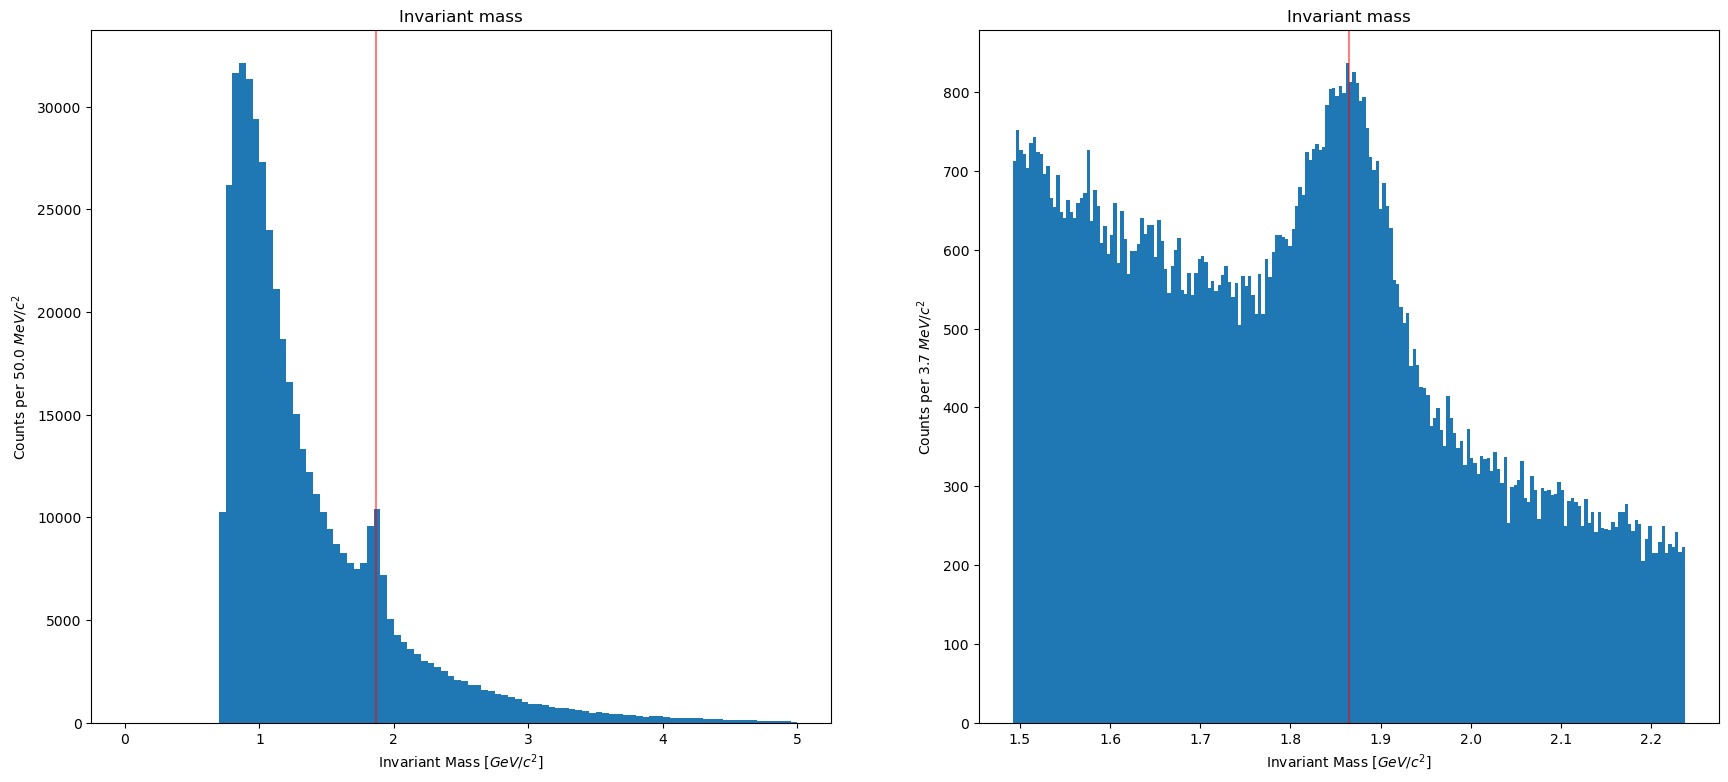

In [11]:
# Now with some filtering
COS_CUT = 0.90
PT_MIN, PT_MAX = 3, 4                                   # +infinity is np.inf
MASS_MIN, MASS_MAX = 0, 5
DCA_CUT = 3e-03
N_BINS = 100

# Recommended to try and comment some masks to see their effect

mask_list = []
# cosine of pointing angle mask
mask_list.append( df["cos_pointing"] >= COS_CUT )

# transverse momentum of D0 mask
#mask_list.append( df["pt"].between(PT_MIN, PT_MAX) )

# invariant mass mask for restrictions in the graph
mask_list.append( (df["inv_mass"].between(MASS_MIN, MASS_MAX)) )


# dcaXY_product mask
#mask_list.append( df["dcaXY_product"].abs() < (DCA_CUT)**2  )

# convert to numpy array and make logical and across the row
mask = np.array(mask_list)
mask = np.all(mask, axis=0)

d0_closer = ((df["inv_mass"] - m_d0).abs() ) < ((df["anti_mass"] - m_d0).abs() )

fig, ax = plt.subplots(1,2, figsize=(21,9) )
ax[0].hist(np.where(d0_closer, df["inv_mass"], df["anti_mass"])[mask],range=(MASS_MIN,MASS_MAX), bins=N_BINS)
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {((MASS_MAX-MASS_MIN)/N_BINS *1000):.1f} $MeV/c^2$")
ax[0].set_title(f"Invariant mass")

M_min, M_max = 0.8, 1.2
N_bins = 200
ax[1].hist(np.where(d0_closer, df["inv_mass"], df["anti_mass"])[mask],range=(m_d0*M_min,m_d0*M_max), bins=N_bins)
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {(((M_max-M_min)*m_d0)/N_bins *1000):.1f} $MeV/c^2$")
ax[1].set_title(f"Invariant mass")
#plt.savefig("Habemus_D0.png")
plt.show()

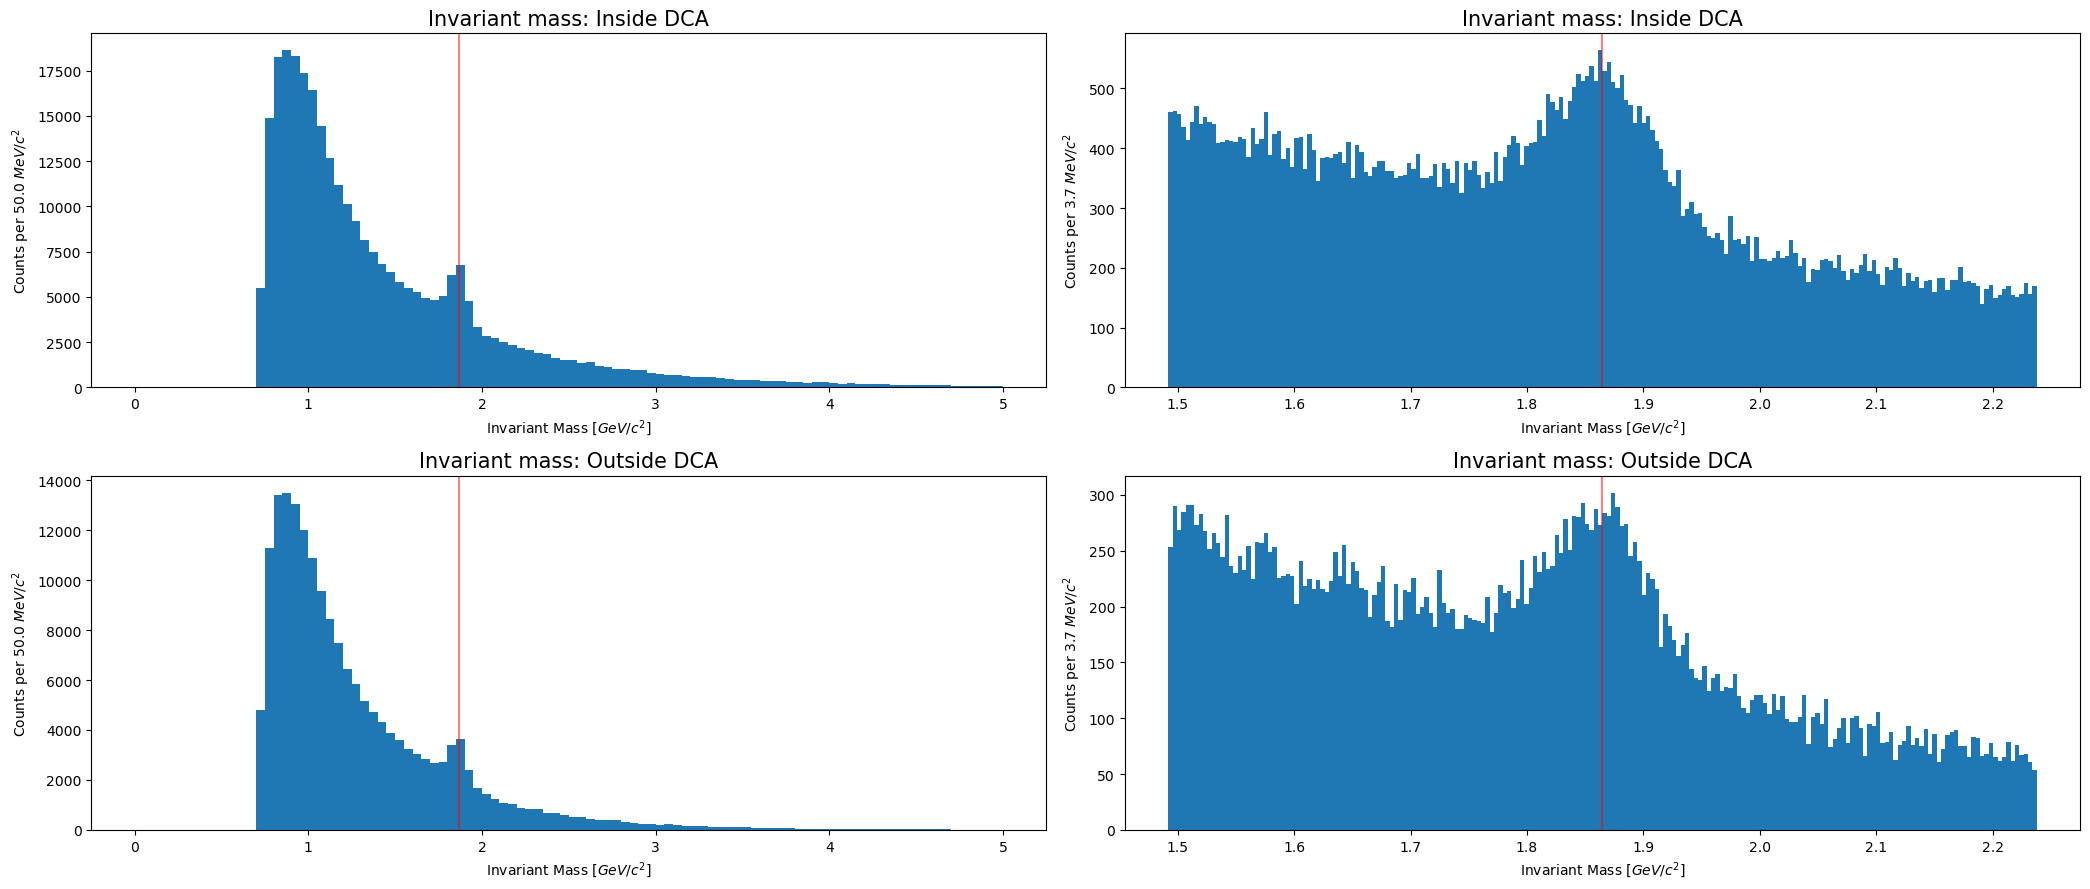

In [12]:
# Should we keep the inside or outside of the DCA region?
mask_list = []
# cosine of pointing angle mask
mask_list.append( df["cos_pointing"] >= COS_CUT )

# transverse momentum of D0 mask
#mask_list.append( df["pt"].between(PT_MIN, PT_MAX) )

# invariant mass mask for restrictions in the graph
mask_list.append( (df["inv_mass"].between(MASS_MIN, MASS_MAX)) )

# dcaXY_product mask
mask_list.append( df["dcaXY_product"].abs() < (DCA_CUT)**2  )

# convert to numpy array and make logical and across the row
mask = np.array(mask_list)
mask = np.all(mask, axis=0)

d0_closer = ((df["inv_mass"] - m_d0).abs() ) < ((df["anti_mass"] - m_d0).abs() )

fig, ax = plt.subplots(2,2, figsize=(21,9) )
ax[0][0].hist(np.where(d0_closer, df["inv_mass"], df["anti_mass"])[mask],range=(MASS_MIN,MASS_MAX), bins=N_BINS)
ax[0][0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0][0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0][0].set_ylabel(f"Counts per {((MASS_MAX-MASS_MIN)/N_BINS *1000):.1f} $MeV/c^2$")
ax[0][0].set_title(f"Invariant mass: Inside DCA", fontsize=15)

M_min, M_max = 0.8, 1.2
N_bins = 200
ax[0][1].hist(np.where(d0_closer, df["inv_mass"], df["anti_mass"])[mask],range=(m_d0*M_min,m_d0*M_max), bins=N_bins)
ax[0][1].axvline(x=m_d0, color="red", alpha=0.5)
ax[0][1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0][1].set_ylabel(f"Counts per {(((M_max-M_min)*m_d0)/N_bins *1000):.1f} $MeV/c^2$")
ax[0][1].set_title(f"Invariant mass: Inside DCA", fontsize=15)

mask_list = []
# cosine of pointing angle mask
mask_list.append( df["cos_pointing"] >= COS_CUT )

# transverse momentum of D0 mask
#mask_list.append( df["pt"].between(PT_MIN, PT_MAX) )

# invariant mass mask for restrictions in the graph
mask_list.append( (df["inv_mass"].between(MASS_MIN, MASS_MAX)) )

# dcaXY_product mask
mask_list.append( df["dcaXY_product"].abs() >= (DCA_CUT)**2  )

# convert to numpy array and make logical and across the row
mask = np.array(mask_list)
mask = np.all(mask, axis=0)

ax[1][0].hist(np.where(d0_closer, df["inv_mass"], df["anti_mass"])[mask],range=(MASS_MIN,MASS_MAX), bins=N_BINS)
ax[1][0].axvline(x=m_d0, color="red", alpha=0.5)
ax[1][0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1][0].set_ylabel(f"Counts per {((MASS_MAX-MASS_MIN)/N_BINS *1000):.1f} $MeV/c^2$")
ax[1][0].set_title(f"Invariant mass: Outside DCA", fontsize=15)

ax[1][1].hist(np.where(d0_closer, df["inv_mass"], df["anti_mass"])[mask],range=(m_d0*M_min,m_d0*M_max), bins=N_bins)
ax[1][1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1][1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1][1].set_ylabel(f"Counts per {(((M_max-M_min)*m_d0)/N_bins *1000):.1f} $MeV/c^2$")
ax[1][1].set_title(f"Invariant mass: Outside DCA", fontsize=15)

plt.tight_layout()
#plt.savefig("DCA_Comparison.png")
plt.show()


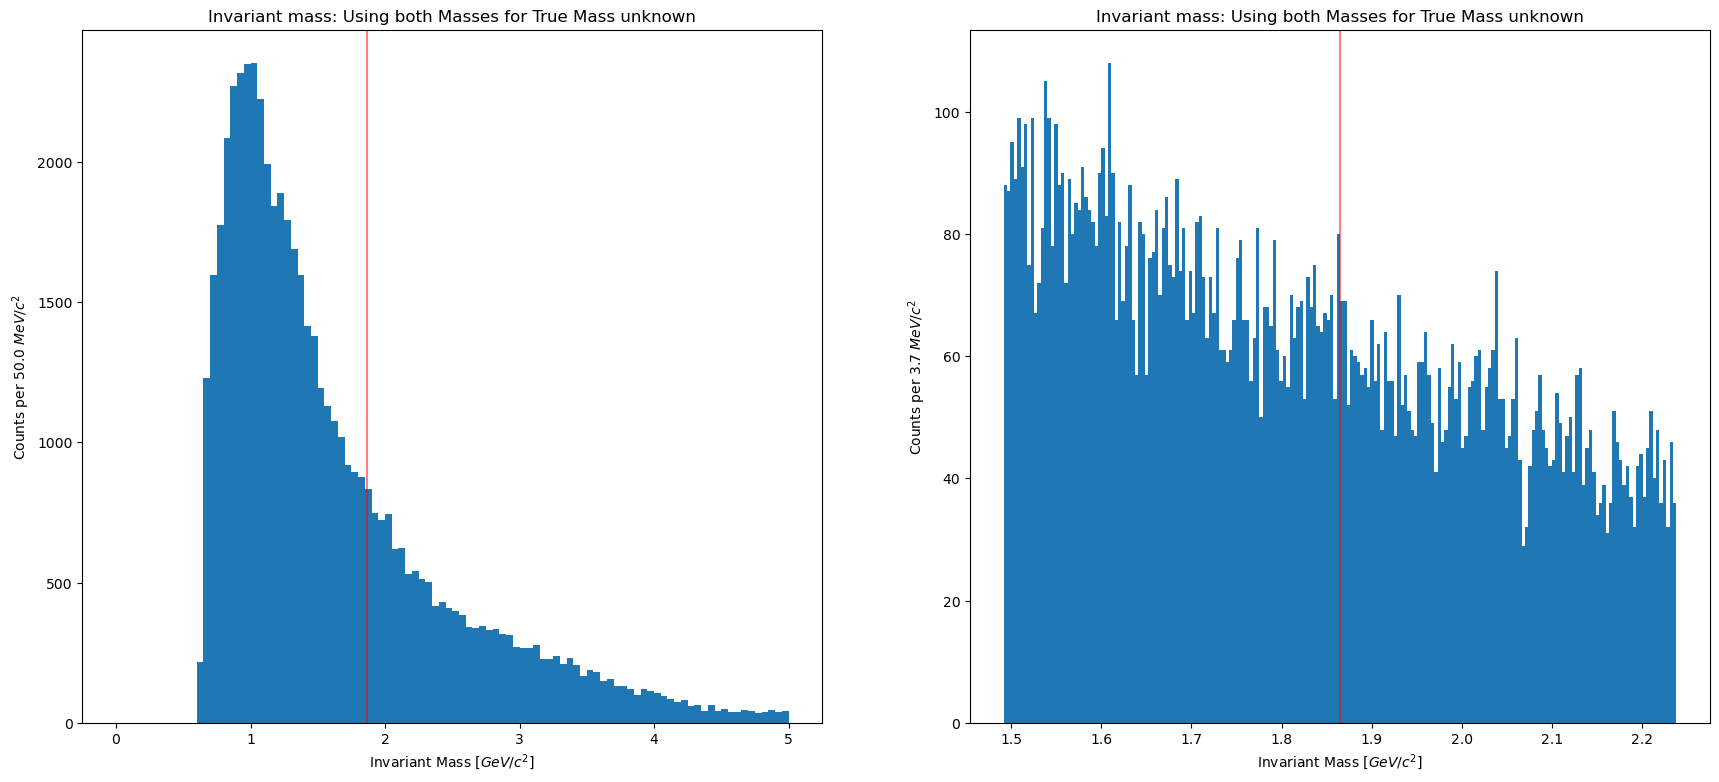

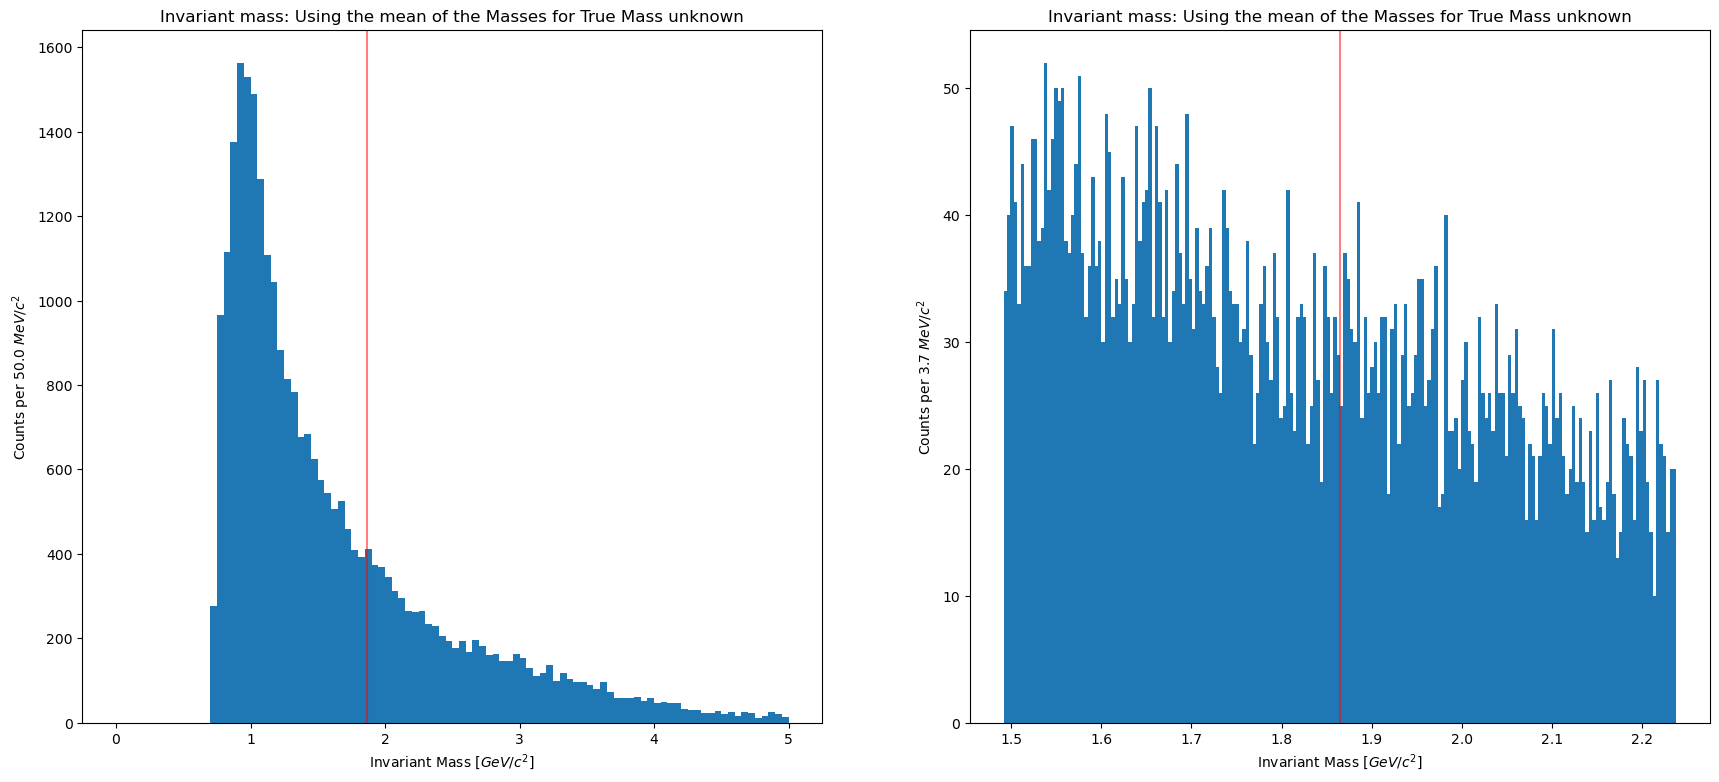

In [13]:
# what if I don't want to use the true mass?

# Option 1: Use Both
mask_list = []
# cosine of pointing angle mask
mask_list.append( df["cos_pointing"] >= COS_CUT )

# transverse momentum of D0 mask
mask_list.append( df["pt"].between(PT_MIN, PT_MAX) )

# invariant mass mask for restrictions in the graph
#mask_list.append( (df["inv_mass"].between(MASS_MIN, MASS_MAX)) )

# dcaXY_product mask
mask_list.append( df["dcaXY_product"].abs() < (DCA_CUT)**2  )

# convert to numpy array and make logical and across the row
mask = np.array(mask_list)
mask = np.all(mask, axis=0)

both_masses = df[mask][["inv_mass", "anti_mass"]]
both_masses = pd.concat([ both_masses["inv_mass"], both_masses["anti_mass"] ] )

fig, ax = plt.subplots(1,2, figsize=(21,9) )
ax[0].hist(both_masses,range=(MASS_MIN,MASS_MAX), bins=N_BINS)
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {((MASS_MAX-MASS_MIN)/N_BINS *1000):.1f} $MeV/c^2$")
ax[0].set_title(f"Invariant mass: Using both Masses for True Mass unknown")

M_min, M_max = 0.8, 1.2
N_bins = 200
ax[1].hist(both_masses,range=(m_d0*M_min,m_d0*M_max), bins=N_bins)
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {(((M_max-M_min)*m_d0)/N_bins *1000):.1f} $MeV/c^2$")
ax[1].set_title(f"Invariant mass: Using both Masses for True Mass unknown")
plt.show()

# Option 2: Use the mean
mask_list = []
# cosine of pointing angle mask
mask_list.append( df["cos_pointing"] >= COS_CUT )

# transverse momentum of D0 mask
mask_list.append( df["pt"].between(PT_MIN, PT_MAX) )

# invariant mass mask for restrictions in the graph
#mask_list.append( (df["inv_mass"].between(MASS_MIN, MASS_MAX)) )


# dcaXY_product mask
mask_list.append( df["dcaXY_product"].abs() < (DCA_CUT)**2  )

# convert to numpy array and make logical and across the row
mask = np.array(mask_list)
mask = np.all(mask, axis=0)

fig, ax = plt.subplots(1,2, figsize=(21,9) )
ax[0].hist(( df["inv_mass"][mask]+df["anti_mass"][mask])/2,range=(MASS_MIN,MASS_MAX), bins=N_BINS)
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {((MASS_MAX-MASS_MIN)/N_BINS *1000):.1f} $MeV/c^2$")
ax[0].set_title(f"Invariant mass: Using the mean of the Masses for True Mass unknown")

M_min, M_max = 0.8, 1.2
N_bins = 200
ax[1].hist(( df["inv_mass"][mask]+df["anti_mass"][mask])/2,range=(m_d0*M_min,m_d0*M_max), bins=N_bins)
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {(((M_max-M_min)*m_d0)/N_bins *1000):.1f} $MeV/c^2$")
ax[1].set_title(f"Invariant mass: Using the mean of the Masses for True Mass unknown")
plt.show()

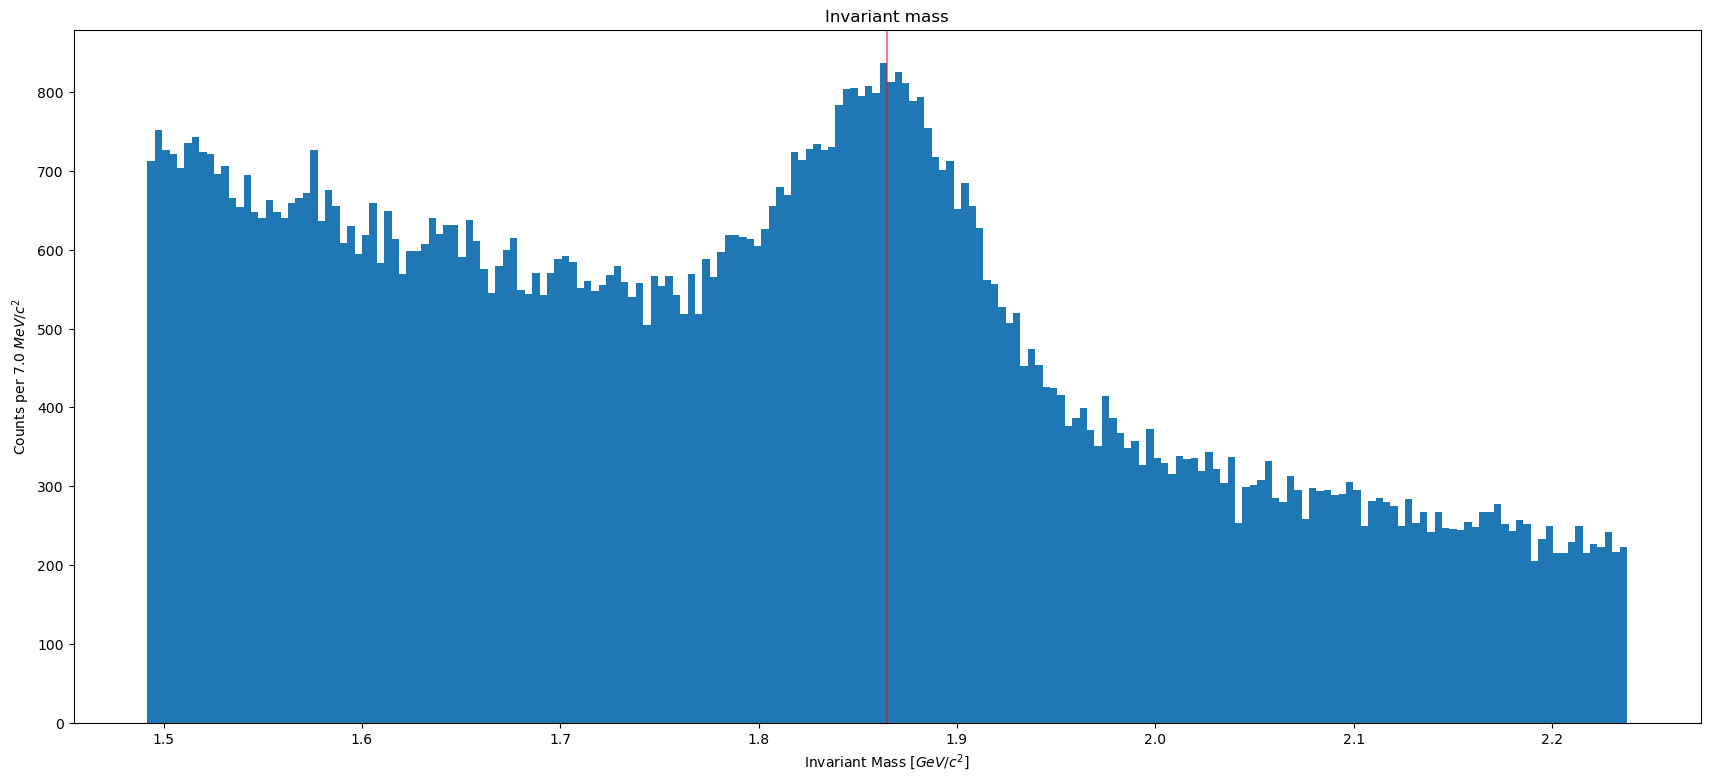

,mass,dcaXY,pt,cos_pointing,decay_length
0,2.069586,-9.161498e-08,3.217463,0.973469,0.008982
1,1.559158,-3.049952e-07,0.548825,0.917019,0.008780
2,1.889124,-6.477361e-06,4.730274,0.985681,0.078153
3,1.689893,-2.458856e-06,10.420615,0.998587,0.015628
4,1.720354,-4.515217e-06,5.402737,0.999409,0.017386


The final dataframe has 100688 rows and  5 columns.
The final dataframe occupies 3.84 MB
Dataframe saved as Final_Chunk1300.pkl.


In [14]:
# settings to save in order to build the mass histograms.
m_d0 = 1.86484
COS_CUT = 0.90
M_min, M_max = 0.8*m_d0, 1.2*m_d0

mask_list = []
# cosine of pointing angle mask
mask_list.append( df["cos_pointing"] >= COS_CUT )

#mass mask
mask_list.append( (df["inv_mass"].between(M_min, M_max)) | (df["anti_mass"].between(M_min, M_max))  )

# convert to numpy array and make logical and across the row
mask = np.array(mask_list)
mask = np.all(mask, axis=0)

d0_closer = ((df["inv_mass"] - m_d0).abs() ) < ((df["anti_mass"] - m_d0).abs() )

fig, ax = plt.subplots(figsize=(21,9))
N_bins = 200
ax.hist(np.where(d0_closer, df["inv_mass"], df["anti_mass"])[mask],range=(M_min, M_max), bins=N_bins)
ax.axvline(x=m_d0, color="red", alpha=0.5)
ax.set_xlabel("Invariant Mass $[GeV/c^2]$")
ax.set_ylabel(f"Counts per {(((M_max-M_min)*m_d0)/N_bins *1000):.1f} $MeV/c^2$")
ax.set_title(f"Invariant mass")

plt.show()

out_df = pd.DataFrame( {
    "mass": np.where(d0_closer, df["inv_mass"], df["anti_mass"])[mask],
    "dcaXY": df["dcaXY_product"][mask],
    "pt": df["pt"][mask],
    "cos_pointing": df["cos_pointing"][mask],
    "decay_length": df["decay_length"][mask]
})
out_df.reset_index(inplace=True, drop=True)
display(out_df.head())

print("The final dataframe has", len(out_df), "rows and ", len(out_df.columns), "columns.")
memory = out_df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The final dataframe occupies {memory:.2f} MB")

output_name = "Final_" + which_chunk + ".pkl"
out_df.to_pickle(output_name)
print(f"Dataframe saved as {output_name}.")